# Curated Space Objects Dataset

This notebook works with a curated dataset of beautiful and well-known space objects: names, types, descriptions, images, and mood metadata.

The idea is a playful model: given a person's photo, the system picks the closest space object and returns its name, description, mood, and image.

This is not classical supervised classification with many images per class. For this use case, embeddings and nearest-neighbor matching are a better starting point.


In [ ]:
!pip install -q pandas numpy matplotlib pillow requests tqdm scikit-learn sentence-transformers deep-translator

## Imports and Settings

In [ ]:
from pathlib import Path
import json
import re
import time
import urllib.parse
import hashlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.auto import tqdm

DATA_DIR = Path('data/curated_space_objects')
SEED_CSV_PATH = DATA_DIR / 'space_objects_seed.csv'
IMAGE_DIR = DATA_DIR / 'images'
CSV_PATH = DATA_DIR / 'space_objects.csv'  # archival intermediate file
FINAL_CSV_PATH = DATA_DIR / 'space_objects_data.csv'
EMBEDDINGS_PATH = DATA_DIR / 'space_object_embeddings.npy'
BIAS_PATH = DATA_DIR / 'space_object_person_bias.npy'
CARD_DIR = DATA_DIR / 'cards'

DATA_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_DIR.mkdir(parents=True, exist_ok=True)
CARD_DIR.mkdir(parents=True, exist_ok=True)

# Safety flags: keep downloads explicit.
DOWNLOAD_OBJECT_IMAGES = False   # Set True only if object images need to be downloaded
ENRICH_RU_METADATA = False       # Archival: no longer needed; final texts live in FINAL_CSV_PATH
DOWNLOAD_CALIBRATION_PEOPLE = True
DOWNLOAD_TEST_PEOPLE = True

RUN_ARCHIVE_DATASET_BUILD = False  # archival build cells are documented but should not be run by default


## Archive: Seed Object List from CSV

This section documents how the dataset was originally assembled. The seed file `space_objects_seed.csv` contains initial object names, wiki titles, object types, and starting mood values. The main working file has already been built: `space_objects_data.csv`.

Normal workflow: **do not run the archive build cells**; read the final CSV below instead.


In [ ]:
if not RUN_ARCHIVE_DATASET_BUILD:
    print('Archive seed inspection skipped. Main pipeline reads FINAL_CSV_PATH below.')
else:
    required_seed_cols = ['name', 'wiki_title', 'object_type', 'mood', 'tags', 'fallback_image_url']

    seed_df = pd.read_csv(SEED_CSV_PATH).fillna('')
    missing_cols = sorted(set(required_seed_cols) - set(seed_df.columns))
    if missing_cols:
        raise ValueError(f'В seed CSV не хватает колонок: {missing_cols}')

    if seed_df['name'].duplicated().any():
        display(seed_df[seed_df['name'].duplicated(keep=False)].sort_values('name'))
        raise ValueError('В seed CSV есть дубли name')

    seed_objects = seed_df.to_dict('records')
    print('Objects in seed:', len(seed_df))
    display(seed_df['object_type'].value_counts().rename_axis('object_type').reset_index(name='count'))
    seed_df.head()


Archive seed inspection skipped. Main pipeline reads FINAL_CSV_PATH below.


## Archive: Downloading Descriptions and Images from Wikipedia

This cell is kept as documentation for the old build process. It used to fetch English descriptions and images from Wikipedia/Wikimedia. The images and texts are already prepared now, so this block is disabled with `RUN_ARCHIVE_DATASET_BUILD = False` and is not needed for normal runs.


In [ ]:
if not RUN_ARCHIVE_DATASET_BUILD:
    print('Archive Wikipedia download/build step skipped. Main pipeline reads FINAL_CSV_PATH below.')
else:
    WIKI_SUMMARY_URL = 'https://en.wikipedia.org/api/rest_v1/page/summary/{title}'
    WIKI_CACHE_DIR = DATA_DIR / 'wiki_cache'
    WIKI_CACHE_DIR.mkdir(parents=True, exist_ok=True)

    HEADERS = {
        'User-Agent': 'curated-space-objects-notebook/0.1 (educational dataset; contact: local-notebook)'
    }
    REQUEST_DELAY_SECONDS = 2.0
    MAX_RETRIES = 5
    MAX_IMAGE_RETRIES = 1

    def safe_filename(text):
        text = text.lower().replace('&', 'and')
        text = re.sub(r'[^a-z0-9]+', '_', text)
        return text.strip('_')

    def request_json_with_retry(url):
        for attempt in range(MAX_RETRIES):
            response = requests.get(url, headers=HEADERS, timeout=30)
            if response.status_code == 429:
                retry_after = response.headers.get('Retry-After')
                wait_seconds = int(retry_after) if retry_after and retry_after.isdigit() else 2 ** attempt * 10
                print(f'429 Too Many Requests. Waiting {wait_seconds}s...')
                time.sleep(wait_seconds)
                continue
            response.raise_for_status()
            return response.json()
        response.raise_for_status()

    def fetch_wikipedia_summary(title):
        cache_path = WIKI_CACHE_DIR / f'{safe_filename(title)}.json'
        if cache_path.exists():
            return json.loads(cache_path.read_text(encoding='utf-8'))

        url = WIKI_SUMMARY_URL.format(title=urllib.parse.quote(title, safe=''))
        data = request_json_with_retry(url)
        cache_path.write_text(json.dumps(data, ensure_ascii=False, indent=2), encoding='utf-8')
        time.sleep(REQUEST_DELAY_SECONDS)
        return data

    def download_image(url, image_path):
        if not isinstance(url, str) or not url:
            return None
        if image_path.exists():
            return image_path
        for attempt in range(MAX_IMAGE_RETRIES):
            response = requests.get(url, headers=HEADERS, timeout=60)
            if response.status_code == 429:
                wait_seconds = 5
                print(f'429 while downloading image. Skipping after {wait_seconds}s: {image_path.name}')
                time.sleep(wait_seconds)
                return None
            response.raise_for_status()
            image_path.write_bytes(response.content)
            return image_path
        return None

    def existing_image_is_valid(row):
        image_path = row.get('image_path')
        return isinstance(image_path, str) and image_path and Path(image_path).exists()

    existing_df = pd.read_csv(CSV_PATH).fillna('') if CSV_PATH.exists() else pd.DataFrame()
    existing_by_name = existing_df.set_index('name').to_dict('index') if not existing_df.empty else {}

    rows = []
    for item in tqdm(seed_df.to_dict('records')):
        existing_row = existing_by_name.get(item['name'])
        if existing_row and existing_image_is_valid(existing_row):
            rows.append({**item, **existing_row})
            continue

        row = dict(item)
        try:
            summary = fetch_wikipedia_summary(row['wiki_title'])
            row['description'] = summary.get('extract', '')
            row['wiki_url'] = summary.get('content_urls', {}).get('desktop', {}).get('page')
            row['thumbnail_url'] = summary.get('thumbnail', {}).get('source')

            image_url = row.get('fallback_image_url') or row.get('thumbnail_url')
            image_path = IMAGE_DIR / f"{safe_filename(row['name'])}.jpg"
            if image_path.exists():
                downloaded_path = image_path
            elif DOWNLOAD_OBJECT_IMAGES:
                downloaded_path = download_image(image_url, image_path)
            else:
                downloaded_path = None
                print(f"Skipping image download for {row['name']} because DOWNLOAD_OBJECT_IMAGES=False")
            row['image_path'] = str(downloaded_path) if downloaded_path else row.get('image_path', '')
            row['image_url_used'] = image_url or ''
            row['error'] = ''
        except Exception as exc:
            row['description'] = ''
            row['wiki_url'] = None
            row['thumbnail_url'] = None
            row['image_path'] = ''
            row['image_url_used'] = row.get('fallback_image_url', '')
            row['error'] = repr(exc)
        rows.append(row)

    objects_df = pd.DataFrame(rows)
    objects_df['image_path'] = np.where(objects_df['name']=='Butterfly Nebula',
             'data/curated_space_objects/images/butterfly_nebula.jpg',
             objects_df['image_path'])
    objects_df.to_csv(CSV_PATH, index=False)
    print(objects_df.shape)
    objects_df.head()


Archive Wikipedia download/build step skipped. Main pipeline reads FINAL_CSV_PATH below.


## Archive: Russian Names and Descriptions via Translation

This cell is kept only as pipeline history. The final Russian/English names, descriptions, and mood values already live in `space_objects_description_updated_v2.csv`. This block is not needed for normal runs.


In [ ]:
if not RUN_ARCHIVE_DATASET_BUILD:
    print('Archive RU translation step skipped. Main pipeline reads FINAL_CSV_PATH below.')
else:
    RU_TYPE_NAMES = {
        'galaxy': 'галактика',
        'nebula': 'туманность',
        'dark nebula': 'темная туманность',
        'reflection nebula': 'отражательная туманность',
        'planetary nebula': 'планетарная туманность',
        'supernova remnant': 'остаток сверхновой',
        'supernova': 'сверхновая',
        'star cluster': 'звездное скопление',
        'open cluster': 'рассеянное скопление',
        'globular cluster': 'шаровое скопление',
        'planet': 'планета',
        'moon': 'спутник',
        'minor planet': 'малая планета',
        'dwarf planet': 'карликовая планета',
        'asteroid': 'астероид',
        'trans-Neptunian object': 'транснептуновый объект',
        'black hole': 'черная дыра',
        'black hole / galaxy': 'черная дыра / галактика',
        'quasar': 'квазар',
        'blazar': 'блазар',
        'pulsar': 'пульсар',
        'gravitational lens': 'гравитационная линза',
    }

    try:
        from deep_translator import GoogleTranslator
    except ImportError as exc:
        raise ImportError('Установите deep-translator: !pip install -q deep-translator') from exc

    translator_en_ru = GoogleTranslator(source='en', target='ru')

    TRANSLATE_RU_METADATA = True
    TRANSLATION_SLEEP_SECONDS = 0.4

    def has_cyrillic(text):
        return isinstance(text, str) and bool(re.search(r'[А-Яа-яЁё]', text))

    def needs_ru_translation(text):
        return not has_cyrillic(text)

    def translate_en_to_ru(text, max_chars=4500):
        if not isinstance(text, str) or not text.strip():
            return ''
        text = text.strip()
        if has_cyrillic(text):
            return text
        # GoogleTranslator has practical request limits; keep descriptions compact.
        if len(text) > max_chars:
            text = text[:max_chars].rsplit(' ', 1)[0]
        translated = translator_en_ru.translate(text)
        time.sleep(TRANSLATION_SLEEP_SECONDS)
        return translated or ''

    objects_df = pd.read_csv(CSV_PATH).fillna('')

    for col in ['name_en', 'description_en', 'object_type_en', 'name_ru', 'description_ru', 'object_type_ru']:
        if col not in objects_df.columns:
            objects_df[col] = ''

    objects_df['name_en'] = np.where(objects_df['name_en'].astype(bool), objects_df['name_en'], objects_df['name'])
    objects_df['description_en'] = np.where(objects_df['description_en'].astype(bool), objects_df['description_en'], objects_df['description'])
    objects_df['object_type_en'] = np.where(objects_df['object_type_en'].astype(bool), objects_df['object_type_en'], objects_df['object_type'])

    if not TRANSLATE_RU_METADATA:
        print('Skipping translation because TRANSLATE_RU_METADATA=False')
    else:
        for idx, row in tqdm(objects_df.iterrows(), total=len(objects_df)):
            try:
                if needs_ru_translation(row.get('name_ru', '')):
                    objects_df.at[idx, 'name_ru'] = translate_en_to_ru(row.get('name_en') or row.get('name'))

                if needs_ru_translation(row.get('description_ru', '')):
                    objects_df.at[idx, 'description_ru'] = translate_en_to_ru(row.get('description_en') or row.get('description'))

                object_type = row.get('object_type_en') or row.get('object_type')
                objects_df.at[idx, 'object_type_ru'] = RU_TYPE_NAMES.get(object_type, translate_en_to_ru(object_type))

                # Save after every row to keep progress if translation limits interrupt the cell.
                objects_df.to_csv(CSV_PATH, index=False)
            except Exception as exc:
                print(f"Translation failed for {row.get('name', idx)}: {exc}")
                objects_df.to_csv(CSV_PATH, index=False)

    objects_df.to_csv(CSV_PATH, index=False)

    display(pd.DataFrame({
        'objects': [len(objects_df)],
        'with_name_ru': [objects_df['name_ru'].map(has_cyrillic).sum()],
        'with_description_ru': [objects_df['description_ru'].map(has_cyrillic).sum()],
        'with_object_type_ru': [objects_df['object_type_ru'].map(has_cyrillic).sum()],
    }))
    objects_df[['name_en', 'name_ru', 'object_type_en', 'object_type_ru', 'description_ru']].head(10)


Archive RU translation step skipped. Main pipeline reads FINAL_CSV_PATH below.


## Main Dataset

From this point on, the notebook uses only the final file `data/curated_space_objects/space_objects_data.csv`. It already contains local image paths, English/Russian names, object types, descriptions, and mood fields (`mood_en`, `mood_ru`).


In [ ]:
objects_df = pd.read_csv(FINAL_CSV_PATH).fillna('')

# Backward-compatible base columns (some cells still use name/object_type/mood/description).
for base_col, en_col in [
    ('name', 'name_en'),
    ('object_type', 'object_type_en'),
    ('description', 'description_en'),
    ('mood', 'mood_en'),
]:
    if en_col not in objects_df.columns:
        continue
    if base_col not in objects_df.columns:
        objects_df[base_col] = objects_df[en_col]
    else:
        objects_df[base_col] = np.where(
            objects_df[base_col].astype(str).str.strip().astype(bool),
            objects_df[base_col],
            objects_df[en_col],
        )

objects_df['has_image'] = objects_df['image_path'].map(lambda p: bool(p) and Path(p).exists())

required_final_cols = [
    'name_en', 'name_ru', 'description_en', 'description_ru',
    'object_type_en', 'object_type_ru', 'mood_en', 'mood_ru', 'image_path'
]
missing_cols = sorted(set(required_final_cols) - set(objects_df.columns))
if missing_cols:
    raise ValueError(f'В финальном CSV не хватает колонок: {missing_cols}')

summary = pd.DataFrame(
    {
        'objects': [len(objects_df)],
        'with_images': [int(objects_df['has_image'].sum())],
        'without_images': [int((~objects_df['has_image']).sum())],
        'types_en': [objects_df['object_type_en'].nunique()],
    }
)
display(summary)
display(objects_df['object_type_en'].value_counts().rename_axis('object_type_en').reset_index(name='count'))
display(objects_df.loc[~objects_df['has_image'], ['name_en', 'name_ru', 'image_path']])
objects_df[['name_en', 'name_ru', 'object_type_en', 'object_type_ru', 'mood_en', 'mood_ru', 'description_en', 'description_ru', 'image_path']].head(10)


,objects,with_images,without_images,types_en
0,88,85,3,18


,object_type_en,count
0,nebula,21
1,galaxy,18
2,planet,8
3,planetary nebula,7
4,moon,7
5,supernova remnant,5
6,star cluster,4
7,globular cluster,3
8,dark nebula,2
9,reflection nebula,2


,name_en,name_ru,image_path
30,Cat's Eye Nebula,Туманность Кошачий Глаз,data/curated_space_objects/images/cat_s_eye_ne...
46,Elephant's Trunk Nebula,Туманность Слоновий Хобот,data/curated_space_objects/images/elephant_s_t...
49,Thor's Helmet,Шлем Тора,data/curated_space_objects/images/thor_s_helme...


,name_en,name_ru,object_type_en,object_type_ru,mood_en,mood_ru,description_en,description_ru,image_path
0,Andromeda Galaxy,Галактика Андромеды,galaxy,галактика,"majestic, calm, magnetic","величественный, спокойный, притягательный",The Andromeda Galaxy is a barred spiral galaxy...,Галактика Андромеды — спиральная галактика с п...,data/curated_space_objects/images/andromeda_ga...
1,Milky Way,Млечный Путь,galaxy,галактика,"familiar, dreamy, infinite","знакомый, мечтательный, бесконечный",The Milky Way is the galaxy that includes the ...,"Млечный Путь — это галактика, включающая Солне...",data/curated_space_objects/images/milky_way.jpg
2,Sombrero Galaxy,Галактика Сомбреро,galaxy,галактика,"stylish, mysterious, elegant","стильный, загадочный, элегантный",The Sombrero Galaxy is a peculiar galaxy of un...,Галактика Сомбреро — своеобразная галактика не...,data/curated_space_objects/images/sombrero_gal...
3,Whirlpool Galaxy,Галактика Водоворот,galaxy,галактика,"dramatic, social, magnetic","драматичный, общительный, притягательный",The Whirlpool Galaxy is an interacting grand-d...,Галактика Водоворот — это взаимодействующая сп...,data/curated_space_objects/images/whirlpool_ga...
4,Triangulum Galaxy,Галактика Треугольника,galaxy,галактика,"soft, open, luminous","мягкий, открытый, сияющий",The Triangulum Galaxy is a spiral galaxy 2.8 m...,Галактика Треугольника — спиральная галактика ...,data/curated_space_objects/images/triangulum_g...
5,Pinwheel Galaxy,Галактика Вертушка,galaxy,галактика,"playful, bright, structured","игривый, яркий, собранный","The Pinwheel Galaxy is a face-on, counterclock...",Галактика Вертушка — это промежуточная спираль...,data/curated_space_objects/images/pinwheel_gal...
6,Cigar Galaxy,Галактика Сигара,galaxy,галактика,"restless, mysterious, intense","неугомонный, загадочный, интенсивный","Messier 82 (also known as NGC 3034, Cigar Gala...","Мессье 82 (также известная как NGC 3034, Сигар...",data/curated_space_objects/images/cigar_galaxy...
7,Sunflower Galaxy,Галактика Подсолнух,galaxy,галактика,"warm, vibrant, generous","тёплый, живой, щедрый","Messier 63 or M63, also known as NGC 5055 or t...","Мессье 63 или M63, также известная как NGC 505...",data/curated_space_objects/images/sunflower_ga...
8,Black Eye Galaxy,Галактика Черный Глаз,galaxy,галактика,"moody, dramatic, sharp","мрачноватый, драматичный, резкий",The Black Eye Galaxy is a relatively isolated ...,Галактика Черный Глаз — относительно изолирова...,data/curated_space_objects/images/black_eye_ga...
9,Needle Galaxy,Галактика-Игла,galaxy,галактика,"delicate, precise, distant","деликатный, точный, отстранённый",NGC 4565 is an edge-on spiral galaxy about 30 ...,"NGC 4565 — спиральная галактика, видимая с реб...",data/curated_space_objects/images/needle_galax...


## Image Examples

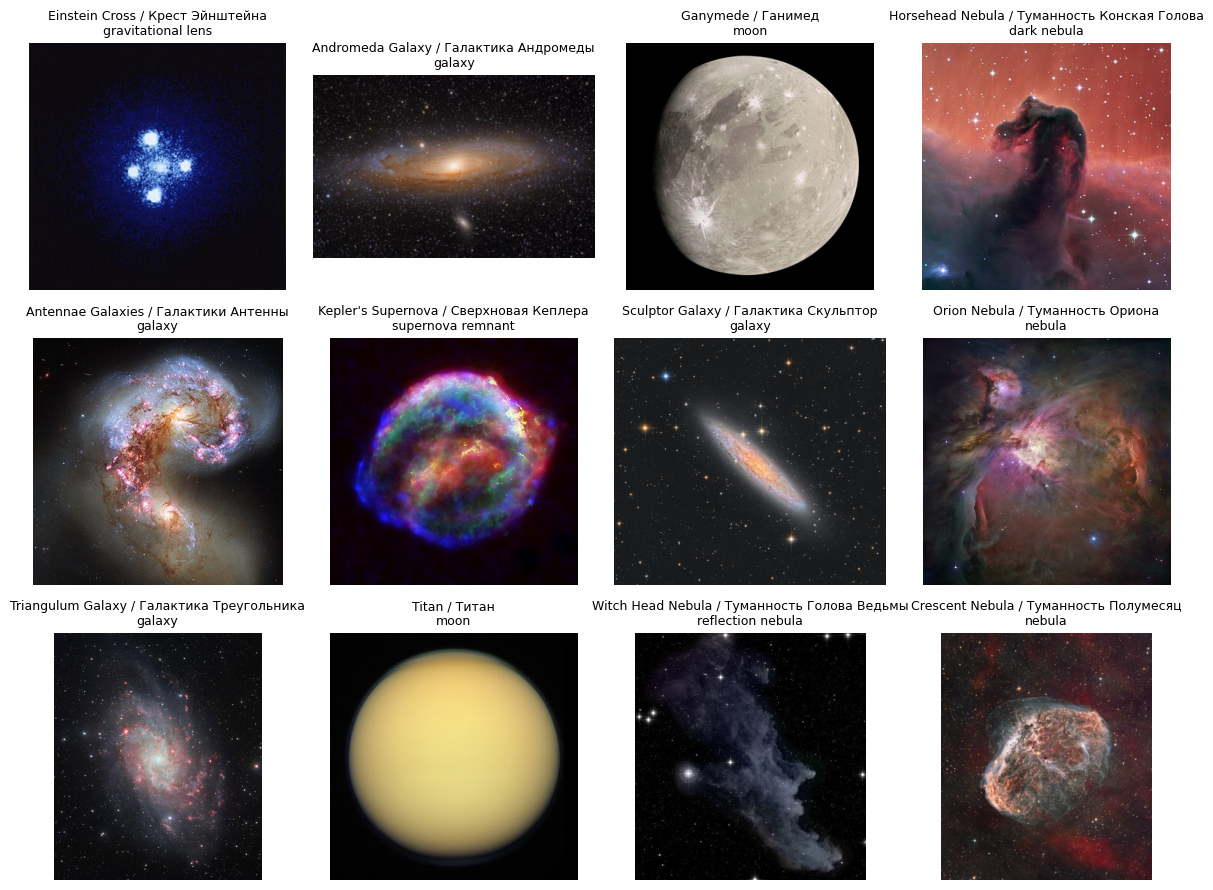

In [ ]:
objects_df['has_image'] = objects_df['image_path'].map(lambda p: bool(p) and Path(p).exists())
examples = objects_df[objects_df['has_image']].sample(n=min(12, int(objects_df['has_image'].sum())), random_state=42)

if examples.empty:
    print('Пока нет скачанных картинок. Проверьте колонку fallback_image_url или перезапустите загрузку позже.')
else:
    plt.figure(figsize=(12, 9))
    for i, row in enumerate(examples.itertuples(index=False)):
        plt.subplot(3, 4, i + 1)
        plt.imshow(Image.open(row.image_path).convert('RGB'))
        plt.title(f'{row.name_en} / {row.name_ru}\n{row.object_type_en}', fontsize=9)
        plt.axis('off')
    plt.tight_layout()


## Baseline: Matching a Person Photo with CLIP

We use `sentence-transformers/clip-ViT-B-32`. It can encode images into embeddings. For each space object, we compute an image embedding. For the input person photo, we compute another embedding and find the closest space objects by cosine similarity.

This works better for the playful prototype than a classifier, because we have very few images per object.


In [ ]:
from sentence_transformers import SentenceTransformer

clip_model = SentenceTransformer('clip-ViT-B-32')

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [ ]:
objects_df['has_image'] = objects_df['image_path'].map(lambda p: bool(p) and Path(p).exists())
objects_with_images = objects_df[objects_df['has_image']].reset_index(drop=True)
if objects_with_images.empty:
    raise ValueError('Нет объектов с локальными картинками. Сначала соберите/докачайте изображения.')

space_images = [Image.open(path).convert('RGB') for path in objects_with_images['image_path']]
space_embeddings = clip_model.encode(space_images, convert_to_numpy=True, show_progress_bar=True, normalize_embeddings=True)
np.save(EMBEDDINGS_PATH, space_embeddings)
space_embeddings.shape


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

(85, 512)

## Calibration Against Overly Popular Objects

If almost every person photo matches the same object, that object probably has a high average cosine similarity to human photos. We estimate `person_bias`: the average similarity of each space object to a small set of calibration face images. During prediction, this bias is subtracted from the score.


In [ ]:
CALIBRATION_IMAGE_DIR = DATA_DIR / 'calibration_people'
CALIBRATION_IMAGE_DIR.mkdir(parents=True, exist_ok=True)

def download_calibration_people(n=8):
    paths = []
    for i in range(n):
        image_path = CALIBRATION_IMAGE_DIR / f'person_{i:02d}.jpg'
        if image_path.exists():
            paths.append(image_path)
            continue
        if not DOWNLOAD_CALIBRATION_PEOPLE:
            print(f'Skipping calibration person download {i} because DOWNLOAD_CALIBRATION_PEOPLE=False')
            continue
        try:
            url = f'https://thispersondoesnotexist.com/?{time.time()}_{i}'
            response = requests.get(url, headers=HEADERS, timeout=60)
            response.raise_for_status()
            image_path.write_bytes(response.content)
            paths.append(image_path)
            time.sleep(1.0)
        except Exception as exc:
            print(f'Cannot download calibration image {i}: {exc}')
    return paths

def build_person_bias(calibration_paths):
    if len(calibration_paths) == 0:
        print('Нет calibration-фото. Bias будет нулевым.')
        return np.zeros(len(objects_with_images), dtype=np.float32)

    calibration_images = [Image.open(path).convert('RGB') for path in calibration_paths]
    calibration_embeddings = clip_model.encode(
        calibration_images,
        convert_to_numpy=True,
        show_progress_bar=True,
        normalize_embeddings=True,
    )
    bias = cosine_similarity(calibration_embeddings, space_embeddings).mean(axis=0)
    np.save(BIAS_PATH, bias)
    return bias

calibration_paths = download_calibration_people(n=8)
person_bias = build_person_bias(calibration_paths)

bias_preview = objects_with_images[['name_en', 'object_type_en']].rename(
    columns={'name_en': 'name', 'object_type_en': 'object_type'}
).copy()
bias_preview['person_bias'] = person_bias
bias_preview.sort_values('person_bias', ascending=False).head(10)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

,name,object_type,person_bias
64,Earth,planet,0.469667
0,Andromeda Galaxy,galaxy,0.462732
8,Black Eye Galaxy,galaxy,0.454925
1,Milky Way,galaxy,0.450808
68,Ganymede,moon,0.445567
5,Pinwheel Galaxy,galaxy,0.442151
76,Arrokoth,trans-Neptunian object,0.440783
19,Crab Nebula,supernova remnant,0.437992
6,Cigar Galaxy,galaxy,0.437782
2,Sombrero Galaxy,galaxy,0.437261


## Predicting a Space Object for One Input Image

In [ ]:
def localized_value(row, base_name, lang='ru'):
    lang = lang.lower()
    col = f'{base_name}_ru' if lang == 'ru' else f'{base_name}_en'
    if hasattr(row, 'get'):
        value = row.get(col, '')
        if isinstance(value, str) and value:
            return value
        return row.get(base_name, '')
    value = getattr(row, col, '')
    if isinstance(value, str) and value:
        return value
    return getattr(row, base_name, '')

def make_funny_description(row, match_percent, lang='ru'):
    name = localized_value(row, 'name', lang)
    object_type = localized_value(row, 'object_type', lang)
    description = localized_value(row, 'description', lang)
    mood = localized_value(row, 'mood', lang)
    short_description = description.split('.')[0] + '.' if isinstance(description, str) and description else ''

    if lang == 'en':
        return (
            f"You are {name}. Object type: {object_type}. "
            f"Vibe: {mood}. "
            f"Cosmic match: {match_percent:.1f}%. "
            f"{short_description}"
        )

    return (
        f"Ты — {name}. Тип объекта: {object_type}. "
        f"Вайб: {mood}. "
        f"Космическое совпадение: {match_percent:.1f}%. "
        f"{short_description}"
    )

def deterministic_seed_from_image(image):
    normalized = image.convert('RGB').resize((128, 128))
    image_bytes = normalized.tobytes()
    digest = hashlib.sha256(image_bytes).digest()
    return int.from_bytes(digest[:8], byteorder='big', signed=False)

def deterministic_jitter(seed, name, low=-3.5, high=3.5):
    digest = hashlib.sha256(f'{seed}:{name}'.encode('utf-8')).digest()
    value = int.from_bytes(digest[:8], byteorder='big', signed=False) / 2**64
    return low + (high - low) * value

def add_fun_match_scores(results, all_adjusted_scores, image_seed):
    results = results.copy()
    all_scores = np.asarray(all_adjusted_scores, dtype=float)
    selected_scores = results['adjusted_score'].to_numpy(dtype=float)

    mean = all_scores.mean()
    std = all_scores.std()
    if std < 1e-9:
        z_scores = np.zeros_like(selected_scores)
    else:
        z_scores = (selected_scores - mean) / std

    percentiles = np.asarray([float((all_scores <= value).mean()) for value in selected_scores])
    z_component = 1 / (1 + np.exp(-(z_scores - 1.25) / 0.85))
    percentile_component = np.clip((percentiles - 0.70) / 0.30, 0, 1)
    combined = 0.80 * z_component + 0.20 * percentile_component

    base_percent = 50 + 36 * combined
    standout_bonus = np.clip((z_scores - 2.0) * 7.0, 0, 10)
    rank_penalty = np.arange(len(results)) * 1.8
    jitters = np.asarray([deterministic_jitter(image_seed, name, low=-2.5, high=2.5) for name in results['name']])

    results['cosmic_match_percent'] = np.clip(base_percent + standout_bonus - rank_penalty + jitters, 45, 98)
    results['score_percentile'] = percentiles
    results['score_z'] = z_scores
    return results

def softmax(values, temperature=0.03):
    values = np.asarray(values, dtype=np.float64)
    values = values / max(temperature, 1e-6)
    values = values - values.max()
    exp_values = np.exp(values)
    return exp_values / exp_values.sum()

def predict_space_object(image_path, top_k=5, bias_strength=1.0, selection='best', temperature=0.03, lang='ru'):
    query_image = Image.open(image_path).convert('RGB')
    image_seed = deterministic_seed_from_image(query_image)
    query_embedding = clip_model.encode([query_image], convert_to_numpy=True, normalize_embeddings=True)
    raw_scores = cosine_similarity(query_embedding, space_embeddings)[0]

    if 'person_bias' in globals():
        scores = raw_scores - bias_strength * person_bias
    elif BIAS_PATH.exists():
        scores = raw_scores - bias_strength * np.load(BIAS_PATH)
    else:
        scores = raw_scores

    top_indices = np.argsort(scores)[::-1][:top_k]

    results = objects_with_images.iloc[top_indices].copy()
    results['raw_score'] = raw_scores[top_indices]
    results['adjusted_score'] = scores[top_indices]
    results = add_fun_match_scores(results, scores, image_seed)

    if selection in {'sample', 'deterministic_sample'} and len(results) > 1:
        probabilities = softmax(results['adjusted_score'].to_numpy(), temperature=temperature)
        if selection == 'deterministic_sample':
            rng = np.random.default_rng(image_seed)
            selected_pos = rng.choice(len(results), p=probabilities)
        else:
            selected_pos = np.random.choice(len(results), p=probabilities)
        best = results.iloc[selected_pos]
    else:
        best = results.iloc[0]

    print(make_funny_description(best, best.cosmic_match_percent, lang=lang))

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(query_image)
    plt.title('Input image' if lang == 'en' else 'Входное фото')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(Image.open(best.image_path).convert('RGB'))
    plt.title(f"{localized_value(best, 'name', lang)}\n{localized_value(best, 'object_type', lang)}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    result_cols = [
        'name_en', 'name_ru', 'object_type_en', 'object_type_ru', 'mood_en', 'mood_ru',
        'cosmic_match_percent', 'score_percentile', 'score_z',
        'raw_score', 'adjusted_score', 'description_en', 'description_ru', 'image_path'
    ]
    return results[[col for col in result_cols if col in results.columns]]


## Result Card Generation

This section builds a shareable image card from the prediction result. It uses the final localized fields from `space_objects_data.csv`: name, object type, mood, description, and the matched object image.


In [ ]:
from PIL import ImageDraw, ImageFont, ImageFilter

CARD_WIDTH = 720
CARD_MAX_HEIGHT = 1400
CARD_MARGIN = 34


def get_font(size, bold=False):
    candidates = [
        '/System/Library/Fonts/Supplemental/Arial Bold.ttf' if bold else '/System/Library/Fonts/Supplemental/Arial.ttf',
        '/System/Library/Fonts/Supplemental/Helvetica Bold.ttf' if bold else '/System/Library/Fonts/Supplemental/Helvetica.ttf',
        '/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf' if bold else '/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf',
    ]
    for candidate in candidates:
        if candidate and Path(candidate).exists():
            return ImageFont.truetype(candidate, size=size)
    return ImageFont.load_default()


def crop_square(image):
    image = image.convert('RGB')
    width, height = image.size
    side = min(width, height)
    left = (width - side) // 2
    top = (height - side) // 2
    return image.crop((left, top, left + side, top + side))


def square_image(image, size):
    return crop_square(image).resize((size, size), Image.Resampling.LANCZOS)


def rounded_image(image, size, radius=28):
    image = square_image(image, size)
    mask = Image.new('L', (size, size), 0)
    draw = ImageDraw.Draw(mask)
    draw.rounded_rectangle((0, 0, size, size), radius=radius, fill=255)
    result = Image.new('RGBA', (size, size), (0, 0, 0, 0))
    result.paste(image, (0, 0), mask)
    return result


def crop_to_aspect(image, target_width, target_height):
    image = image.convert('RGB')
    width, height = image.size
    target_ratio = target_width / target_height
    image_ratio = width / height
    if image_ratio > target_ratio:
        new_width = int(height * target_ratio)
        left = (width - new_width) // 2
        image = image.crop((left, 0, left + new_width, height))
    else:
        new_height = int(width / target_ratio)
        top = (height - new_height) // 2
        image = image.crop((0, top, width, top + new_height))
    return image.resize((target_width, target_height), Image.Resampling.LANCZOS)


def draw_wrapped_text(draw, text, xy, font, fill, max_width, line_spacing=8, max_lines=None):
    words = str(text).split()
    lines = []
    current = ''
    for word in words:
        candidate = f'{current} {word}'.strip()
        if draw.textbbox((0, 0), candidate, font=font)[2] <= max_width:
            current = candidate
        else:
            if current:
                lines.append(current)
            current = word
    if current:
        lines.append(current)

    if max_lines is not None and len(lines) > max_lines:
        lines = lines[:max_lines]
        lines[-1] = lines[-1].rstrip('.,;:') + '...'

    x, y = xy
    line_height = draw.textbbox((0, 0), 'Ag', font=font)[3] + line_spacing
    for line in lines:
        draw.text((x, y), line, font=font, fill=fill)
        y += line_height
    return y


def create_gradient_background(size, top_color=(9, 12, 28), bottom_color=(28, 25, 50)):
    width, height = size
    bg = Image.new('RGB', size, top_color)
    pixels = bg.load()
    for y in range(height):
        ratio = y / max(height - 1, 1)
        color = tuple(int(top_color[i] * (1 - ratio) + bottom_color[i] * ratio) for i in range(3))
        for x in range(width):
            pixels[x, y] = color
    return bg


def create_prediction_card(person_image_path, best_row, lang='ru', output_path=None):
    lang = lang.lower()
    person_image = Image.open(person_image_path).convert('RGB')
    object_image = Image.open(best_row.image_path).convert('RGB')

    name = localized_value(best_row, 'name', lang)
    object_type = localized_value(best_row, 'object_type', lang)
    mood = localized_value(best_row, 'mood', lang)
    description = localized_value(best_row, 'description', lang)
    match_percent = float(best_row.cosmic_match_percent)

    if lang == 'en':
        title_prefix = ''
        title = f'You are: {name}'
        type_label = f'Type: {object_type}'
        vibe_label = f'Vibe: {mood}'
        match_label = f'cosmic match: {match_percent:.1f}%'
        left_label = 'INPUT'
        right_label = 'MATCH'
    else:
        title_prefix = ''
        title = f'Ты — {name}'
        type_label = f'Тип: {object_type}'
        vibe_label = f'Вайб: {mood}'
        match_label = f'совпадение: {match_percent:.1f}%'
        left_label = 'ФОТО'
        right_label = 'ОБЪЕКТ'

    card_size = (CARD_WIDTH, CARD_MAX_HEIGHT)
    card = create_gradient_background(card_size)
    draw = ImageDraw.Draw(card)

    title_prefix_font = get_font(17, bold=True)
    title_font = get_font(32, bold=True)
    meta_font = get_font(21)
    body_font = get_font(22)
    small_font = get_font(17)
    match_font = get_font(19)

    bg_object = crop_square(object_image).resize(card_size, Image.Resampling.LANCZOS).filter(ImageFilter.GaussianBlur(22))
    card = Image.blend(bg_object, card, alpha=0.88)
    draw = ImageDraw.Draw(card)

    frame = (CARD_MARGIN, CARD_MARGIN, CARD_WIDTH - CARD_MARGIN, CARD_MAX_HEIGHT - CARD_MARGIN)
    # Fill the content panel first. The outline is drawn only after dynamic cropping,
    # otherwise old vertical border fragments remain below the final rounded frame.
    draw.rounded_rectangle(frame, radius=34, fill=(15, 18, 35))

    gap = 22
    y_images = 74
    x_left = CARD_MARGIN + 42
    content_w = CARD_WIDTH - 2 * CARD_MARGIN - 84
    image_size = (content_w - gap) // 2
    x_right = x_left + image_size + gap

    person_preview = rounded_image(person_image, image_size, radius=28)
    object_preview = rounded_image(object_image, image_size, radius=28)
    card.paste(person_preview, (x_left, y_images), person_preview)
    card.paste(object_preview, (x_right, y_images), object_preview)

    draw.text((x_left, y_images + image_size + 8), left_label, font=small_font, fill=(160, 166, 200))
    draw.text((x_right, y_images + image_size + 8), right_label, font=small_font, fill=(160, 166, 200))

    y = y_images + image_size + 42
    content_x = CARD_MARGIN + 42

    if title_prefix:
        draw.text((content_x, y), title_prefix, font=title_prefix_font, fill=(165, 154, 232))
        y += 28
    y = draw_wrapped_text(draw, title, (content_x, y), title_font, (255, 255, 255), content_w, line_spacing=8, max_lines=2)
    y += 10

    # Keep the match score secondary, because it is a playful score, not a real probability.
    draw.text((content_x, y), match_label, font=match_font, fill=(165, 154, 232))
    y += 34

    y = draw_wrapped_text(draw, type_label, (content_x, y), meta_font, (210, 215, 244), content_w, line_spacing=7, max_lines=2)
    y += 4
    y = draw_wrapped_text(draw, vibe_label, (content_x, y), meta_font, (210, 215, 244), content_w, line_spacing=7, max_lines=3)
    y += 16
    draw.line((content_x, y, content_x + content_w, y), fill=(78, 82, 118), width=1)
    y += 20

    y = draw_wrapped_text(draw, description, (content_x, y), body_font, (238, 240, 255), content_w, line_spacing=9, max_lines=5)

    final_height = min(CARD_MAX_HEIGHT, max(760, int(y + CARD_MARGIN + 34)))
    card = card.crop((0, 0, CARD_WIDTH, final_height))
    # Keep the outer area neutral after cropping, so no colored strip appears at the bottom.
    neutral_bg = Image.new('RGB', (CARD_WIDTH, final_height), (9, 12, 28))
    panel_mask = Image.new('L', (CARD_WIDTH, final_height), 0)
    mask_draw = ImageDraw.Draw(panel_mask)
    mask_draw.rounded_rectangle(
        (CARD_MARGIN, CARD_MARGIN, CARD_WIDTH - CARD_MARGIN, final_height - CARD_MARGIN),
        radius=34,
        fill=255,
    )
    neutral_bg.paste(card, (0, 0), panel_mask)
    card = neutral_bg
    draw = ImageDraw.Draw(card)
    draw.rounded_rectangle(
        (CARD_MARGIN, CARD_MARGIN, CARD_WIDTH - CARD_MARGIN, final_height - CARD_MARGIN),
        radius=34,
        outline=(87, 80, 132),
        width=2,
    )

    if output_path is None:
        output_path = CARD_DIR / f"card_{Path(person_image_path).stem}_{safe_filename(str(name))}_{lang}.jpg"
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    card.save(output_path, format='JPEG', quality=94)
    return output_path, card


def predict_space_object_card(image_path, top_k=5, bias_strength=1.0, selection='deterministic_sample', lang='ru'):
    best, results, _ = predict_space_object_raw(
        image_path,
        top_k=top_k,
        bias_strength=bias_strength,
        selection=selection,
    )
    card_path, card = create_prediction_card(image_path, best, lang=lang)
    display(card)
    return card_path, results


## Batch Test on Multiple People

In [ ]:
def predict_space_object_raw(image_path, top_k=5, bias_strength=1.0, selection='deterministic_sample', temperature=0.03):
    query_image = Image.open(image_path).convert('RGB')
    image_seed = deterministic_seed_from_image(query_image)
    query_embedding = clip_model.encode([query_image], convert_to_numpy=True, normalize_embeddings=True)
    raw_scores = cosine_similarity(query_embedding, space_embeddings)[0]

    if 'person_bias' in globals():
        scores = raw_scores - bias_strength * person_bias
    elif BIAS_PATH.exists():
        scores = raw_scores - bias_strength * np.load(BIAS_PATH)
    else:
        scores = raw_scores

    top_indices = np.argsort(scores)[::-1][:top_k]
    results = objects_with_images.iloc[top_indices].copy()
    results['raw_score'] = raw_scores[top_indices]
    results['adjusted_score'] = scores[top_indices]
    results = add_fun_match_scores(results, scores, image_seed)

    if selection in {'sample', 'deterministic_sample'} and len(results) > 1:
        probabilities = softmax(results['adjusted_score'].to_numpy(), temperature=temperature)
        if selection == 'deterministic_sample':
            rng = np.random.default_rng(image_seed)
            selected_pos = rng.choice(len(results), p=probabilities)
        else:
            selected_pos = np.random.choice(len(results), p=probabilities)
    else:
        selected_pos = 0

    best = results.iloc[selected_pos]
    return best, results, query_image

def download_test_people(n=12, refresh=False):
    TEST_IMAGE_DIR.mkdir(parents=True, exist_ok=True)
    paths = []
    for i in range(n):
        image_path = TEST_IMAGE_DIR / f'person_{i:02d}.jpg'
        if refresh and image_path.exists():
            image_path.unlink()
        if not image_path.exists():
            if not DOWNLOAD_TEST_PEOPLE:
                print(f'Skipping test person download {i} because DOWNLOAD_TEST_PEOPLE=False')
                continue
            url = f'https://thispersondoesnotexist.com/?batch_{i}_{time.time()}'
            response = requests.get(url, headers=HEADERS, timeout=60)
            response.raise_for_status()
            image_path.write_bytes(response.content)
            time.sleep(1.0)
        paths.append(image_path)
    return paths

def batch_test_people(image_paths, top_k=5, bias_strength=1.0, selection='deterministic_sample', image_size=320, cols=2, lang='ru'):
    image_paths = [Path(path) for path in image_paths if Path(path).exists()]
    if len(image_paths) == 0:
        print(
            'No test images found. Put person photos into '
            f'{TEST_IMAGE_DIR} or set DOWNLOAD_TEST_PEOPLE=True and rerun download_test_people(...).'
        )
        return pd.DataFrame(
            columns=[
                'person_image', 'predicted_object', 'predicted_object_en',
                'object_type', 'object_type_en', 'mood', 'mood_en',
                'cosmic_match_percent', 'score_percentile', 'score_z',
                'raw_score', 'adjusted_score',
            ]
        )

    rows = []
    previews = []

    for image_path in image_paths:
        best, top_results, query_image = predict_space_object_raw(
            image_path,
            top_k=top_k,
            bias_strength=bias_strength,
            selection=selection,
        )
        rows.append(
            {
                'person_image': str(image_path),
                'predicted_object': localized_value(best, 'name', lang),
                'predicted_object_en': localized_value(best, 'name', 'en'),
                'object_type_en': localized_value(best, 'object_type', 'en'),
                'mood_en': localized_value(best, 'mood', 'en'),
                'object_type': localized_value(best, 'object_type', lang),
                'mood': localized_value(best, 'mood', lang),
                'cosmic_match_percent': best.cosmic_match_percent,
                'score_percentile': best.score_percentile,
                'score_z': best.score_z,
                'raw_score': best.raw_score,
                'adjusted_score': best.adjusted_score,
            }
        )
        previews.append((query_image, Image.open(best.image_path).convert('RGB'), best))

    result_df = pd.DataFrame(rows)

    rows_count = int(np.ceil(len(previews) / cols))
    plt.figure(figsize=(7 * cols, 6 * rows_count))
    for i, (person_image, object_image, best) in enumerate(previews):
        person_preview = person_image.resize((image_size, image_size))
        object_preview = object_image.resize((image_size, image_size))
        combined = Image.new('RGB', (image_size * 2, image_size), 'white')
        combined.paste(person_preview, (0, 0))
        combined.paste(object_preview, (image_size, 0))

        plt.subplot(rows_count, cols, i + 1)
        plt.imshow(combined)
        plt.title(
            f"{localized_value(best, 'name', lang)}\n"
            f"{localized_value(best, 'object_type', lang)} | {best.cosmic_match_percent:.1f}%",
            fontsize=13,
        )
        plt.axis('off')
    plt.tight_layout()
    plt.show()

    if 'predicted_object' in result_df.columns and not result_df.empty:
        display(result_df['predicted_object'].value_counts().rename_axis('object').reset_index(name='count'))
    return result_df


In [ ]:
# TEST_IMAGE_DIR = DATA_DIR / 'test_people'
# TEST_IMAGE_DIR.mkdir(parents=True, exist_ok=True)

# test_people_paths = download_test_people(n=20, refresh=False)
# batch_results = batch_test_people(
#     test_people_paths,
#     top_k=2,
#     bias_strength=1.0,
#     selection='deterministic_sample',
#     image_size=320,
#     cols=2,
# )
# batch_results

## Example Prediction for One Person

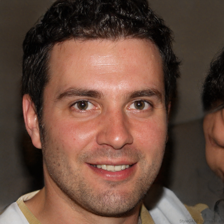

In [ ]:
test_person_path = TEST_IMAGE_DIR / 'person_04.jpg'
test_person_url = 'https://thispersondoesnotexist.com/'

if not test_person_path.exists():
    response = requests.get(test_person_url, headers=HEADERS, timeout=60)
    response.raise_for_status()
    test_person_path.write_bytes(response.content)

img = Image.open(test_person_path).convert('RGB')
img.thumbnail((224, 224)) # Resize the image to 128x128 pixels
img

## Example Card Generation

Run this after `test_person_path` is set and the CLIP embeddings are ready. It creates a card image, displays it, and returns the saved JPG path.


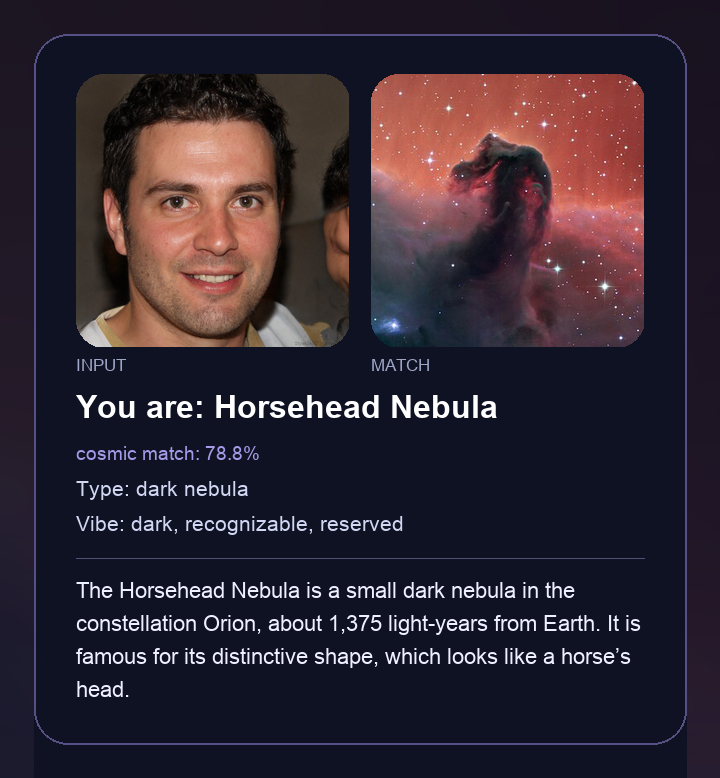

Saved card: data/curated_space_objects/cards/card_person_04_horsehead_nebula_en.jpg


,name_en,name_ru,mood_en,mood_ru,description_en,description_ru,object_type_en,object_type_ru,image_path,name,object_type,description,mood,has_image,raw_score,adjusted_score,cosmic_match_percent,score_percentile,score_z
22,Horsehead Nebula,Туманность Конская Голова,"dark, recognizable, reserved","тёмный, узнаваемый, сдержанный",The Horsehead Nebula is a small dark nebula in...,Туманность Конская Голова — небольшая темная т...,dark nebula,темная туманность,data/curated_space_objects/images/horsehead_ne...,Horsehead Nebula,dark nebula,The Horsehead Nebula is a small dark nebula in...,"dark, recognizable, reserved",True,0.437489,0.041360,78.829362,1.000000,2.066746
39,Cone Nebula,Туманность Конус,"pointed, dark, focused","острый, тёмный, сосредоточенный",The Cone Nebula is an H II region in the const...,Туманность Конус — область H II в созвездии Ед...,nebula,туманность,data/curated_space_objects/images/cone_nebula.jpg,Cone Nebula,nebula,The Cone Nebula is an H II region in the const...,"pointed, dark, focused",True,0.476334,0.040984,76.068325,0.988235,2.031249


In [ ]:
card_path, card_results = predict_space_object_card(
    test_person_path,
    top_k=2,
    bias_strength=1.0,
    selection='deterministic_sample',
    lang='en',
)

print('Saved card:', card_path)
card_results.head()


In [ ]:
# predict_space_object(test_person_path, top_k=2, bias_strength=1.0, selection='deterministic_sample', lang='ru')